# End-to-End MLOps Pipeline for Employee Attrition Prediction

## Project Overview

This project demonstrates the development of a **production-ready machine learning operations (MLOps) pipeline** using the IBM HR Analytics Employee Attrition dataset from Kaggle. The objective is not only to build a predictive machine learning model, but to implement the complete infrastructure, automation, testing, monitoring, and operational workflows required in real-world ML systems.

The project simulates how modern machine learning teams manage the lifecycle of predictive systems by integrating **version control, experiment tracking, automated testing, CI/CD pipelines, data versioning, and drift monitoring** into a unified workflow.

The dataset contains employee-level information such as demographics, job roles, compensation, overtime, work-life balance, and satisfaction metrics. The classification task predicts whether an employee is likely to leave the company, enabling organizations to proactively identify retention risks and improve workforce stability.

Rather than focusing solely on model accuracy, this project emphasizes **reproducibility, maintainability, automation, and monitoring**, mirroring production-grade MLOps practices used in enterprise environments.

---

## Objectives

The primary objective is to build a fully operational **MLOps pipeline** capable of managing machine learning workflows from experimentation through deployment monitoring. Specific goals include:

- Build a reproducible machine learning workflow using **Git, DVC, and MLflow**
- Predict employee attrition using classification models
- Track experiments and compare multiple model configurations
- Implement automated testing with **pytest**
- Create CI/CD workflows using **GitHub Actions**
- Monitor data drift using **Evidently**
- Ensure all workflows are modular, scalable, and production-oriented
- Achieve a reliable classification performance threshold while prioritizing operational robustness

---

## Findings

- Successfully implemented a complete **end-to-end MLOps pipeline** integrating:
  - Git-based version control
  - DVC data versioning
  - MLflow experiment tracking
  - Automated testing with pytest
  - GitHub Actions CI/CD workflows
  - Drift monitoring with Evidently

- Conducted multiple MLflow experiments using varying:
  - Classification algorithms
  - Hyperparameters
  - Feature engineering approaches
  - Data preprocessing configurations

- Identified that features such as:
  - Overtime
  - Monthly income
  - Job satisfaction
  - Years at company
  - Work-life balance  
  were among the strongest indicators of employee attrition risk.

- Built a modular repository structure that separates:
  - Data preprocessing
  - Training
  - Evaluation
  - Monitoring
  - Configuration management
  - Testing workflows

- Automated model validation and performance verification using CI/CD pipelines, ensuring failed models or broken code are rejected before deployment.

- Implemented dataset version tracking using DVC, allowing reproducible experiments across different training runs and environments.

- Developed drift monitoring workflows capable of:
  - Detecting feature distribution changes
  - Generating HTML monitoring reports
  - Triggering alerts when drift thresholds exceed acceptable limits

- Verified pipeline reliability through:
  - Unit testing
  - Data validation testing
  - Model validation testing
  - Automated GitHub Actions execution

---

## Repository Architecture

### Project Structure

```text
project-root/
│
├── configs/
│   └── config.yaml
│
├── data/
│   ├── raw/
│   ├── processed/
│   └── .dvc/
│
├── src/
│   ├── preprocess.py
│   ├── train.py
│   ├── evaluate.py
│   ├── compare_experiments.py
│   └── monitor_drift.py
│
├── tests/
│   ├── test_preprocessing.py
│   ├── test_data_validation.py
│   └── test_model_validation.py
│
├── reports/
│   └── drift_report.html
│
├── .github/
│   └── workflows/
│       └── ci_pipeline.yml
│
├── requirements.txt
├── README.md
├── .gitignore
└── dvc.yaml
```

---

## Project Strategy

### 1. Data Versioning & Repository Management

- Initialize repository with Git and DVC
- Track datasets using DVC instead of Git
- Configure DVC remotes for reproducible data access
- Maintain clean repository organization and modular code structure
- Store hyperparameters and file paths in YAML configuration files

### 2. Data Preprocessing

- Handle missing values and inconsistent data
- Encode categorical variables
- Normalize or scale numerical features where necessary
- Validate schema consistency and feature integrity
- Preserve immutable preprocessing workflows for reproducibility

### 3. Exploratory Data Analysis (EDA)

- Analyze employee demographics and attrition trends
- Examine relationships between overtime, satisfaction, compensation, and turnover
- Identify class imbalance and feature distributions
- Explore correlations between workforce metrics and attrition behavior

### 4. Predictive Modeling

- Train classification models to predict employee attrition
- Compare multiple experiments using MLflow
- Evaluate models using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

- Log:
  - Parameters
  - Metrics
  - Artifacts
  - Model versions
  - Dataset versions

### 5. Automated Testing (pytest)

Implement automated tests for:

#### Unit Testing
- Missing value handling
- Categorical encoding
- Invalid input detection
- Data immutability validation

#### Data Validation
- Expected feature columns
- Target label validation
- Numerical feature range validation

#### Model Validation
- Prediction shape/type verification
- Minimum performance threshold validation

### 6. CI/CD Pipeline Automation

Build GitHub Actions workflows that:

- Trigger on pushes and pull requests
- Run automated test suites
- Execute training pipelines
- Validate model performance thresholds
- Prevent broken models from progressing through the pipeline

### 7. Drift Monitoring & Observability

Use Evidently to:

- Compare training vs. simulated production data
- Detect feature distribution drift
- Generate automated HTML monitoring reports
- Calculate overall drift share
- Trigger alerts when drift exceeds configurable thresholds

---

## Drift Monitoring Insights

The drift monitoring workflow evaluates whether incoming production data significantly differs from the original training distribution.

### Key Monitoring Areas

- Employee compensation changes
- Overtime distribution shifts
- Workforce tenure changes
- Satisfaction score fluctuations
- Department-level hiring pattern changes

### Monitoring Outcomes

- Detect early warning signs of model degradation
- Identify operational or workforce policy changes
- Determine whether retraining is required
- Support continuous monitoring after deployment

---

## Deliverables

- Fully reproducible MLOps pipeline
- Public GitHub repository with organized structure
- DVC-managed datasets and version tracking
- MLflow experiment tracking dashboard
- Automated pytest testing suite
- GitHub Actions CI/CD workflows
- Drift monitoring scripts and HTML reports
- Experiment comparison utilities
- Configuration-driven training workflows
- Documentation and setup instructions

---

## Technologies Used

| Category | Tools & Frameworks |
|---|---|
| Programming | Python |
| Version Control | Git, GitHub, Jupyter Notebook |
| Data Versioning | DVC |
| Experiment Tracking | MLflow |
| Testing | pytest |
| CI/CD | GitHub Actions |
| Drift Monitoring | Evidently |
| ML Libraries | scikit-learn, pandas, NumPy |
| Configuration | YAML |
| Automation | GitHub Workflows |

---

## Summary Insight

This project simulates a real-world machine learning production environment by emphasizing the operational side of machine learning rather than model complexity alone. Through the integration of automated testing, reproducibility, experiment tracking, CI/CD pipelines, and drift monitoring, the project demonstrates how modern ML systems are maintained reliably at scale.

The final pipeline provides a strong foundation for enterprise-ready machine learning workflows where reliability, transparency, monitoring, and maintainability are just as important as predictive performance.

# Data Preprocessing & Exploration

## Initialization

## Environment Setup and Required Libraries

In [1]:
import pandas as pd 
import numpy as np
import glob
import os
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, roc_curve, classification_report, root_mean_squared_error
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from datetime import datetime
from matplotlib.ticker import FuncFormatter
import time
from functools import reduce
from pathlib import Path
import pickle
from typing import Dict, Tuple, Optional
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


things to save 

start = time.time()


In [2]:
df = pd.read_csv('/Users/tjscott23/Documents/MLOps_PL_project/Data/IBM_HR_Attrition.csv')
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,26,Travel_Rarely,1055,Research & Development,9,4,Marketing,2,Female,61,...,3,1,1,2,2,1,0,1,1,Yes
1,18,Travel_Rarely,561,Human Resources,2,3,Life Sciences,3,Female,85,...,4,0,2,4,3,2,0,5,5,No
2,53,Travel_Rarely,1319,Research & Development,4,3,Life Sciences,1,Male,92,...,4,1,6,3,3,6,2,1,1,No
3,52,Travel_Rarely,656,Research & Development,10,3,Life Sciences,3,Female,33,...,1,1,13,3,2,13,12,0,5,No
4,19,Travel_Rarely,991,Sales,20,3,Medical,3,Female,40,...,3,0,9,4,2,9,7,1,0,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EnvironmentSatisfaction   1470 non-null   int64 
 8   Gender                    1470 non-null   object
 9   HourlyRate                1470 non-null   int64 
 10  JobInvolvement            1470 non-null   int64 
 11  JobLevel                  1470 non-null   int64 
 12  JobRole                   1470 non-null   object
 13  JobSatisfaction           1470 non-null   int64 
 14  MaritalStatus           

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,39.102041,787.358503,8.258503,2.891837,2.738776,64.779592,2.884354,2.335374,2.729932,6569.146939,...,3.147619,2.772789,0.853061,6.417687,2.731973,2.790476,6.417687,4.927211,1.689796,3.395238
std,12.233843,402.411986,7.796325,1.035057,1.046792,20.532274,0.837490,1.130570,1.095129,2938.012937,...,0.354843,1.099573,0.853560,7.063436,1.339660,0.695931,7.063436,6.757957,2.194824,3.703931
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,436.500000,2.000000,2.000000,2.000000,47.000000,2.000000,1.000000,2.000000,4478.250000,...,3.000000,2.000000,0.000000,1.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000
50%,39.000000,761.500000,6.000000,3.000000,3.000000,65.000000,3.000000,2.000000,3.000000,6473.500000,...,3.000000,3.000000,1.000000,4.000000,3.000000,3.000000,4.000000,2.000000,1.000000,2.000000
75%,49.000000,1138.500000,11.000000,4.000000,4.000000,82.000000,3.000000,3.000000,4.000000,8554.000000,...,3.000000,4.000000,1.000000,9.000000,3.000000,3.000000,9.000000,7.000000,2.000000,5.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,17132.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,40.000000,15.000000,17.000000


In [5]:
df.duplicated().sum()

np.int64(0)

### Data Loading Summary 

- No Nulls
- Data Types seem appropriate
- Convert Columns to normal naming conventions

## Data Preparation

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
)

df.columns

Index(['age', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field',
       'environment_satisfaction', 'gender', 'hourly_rate', 'job_involvement',
       'job_level', 'job_role', 'job_satisfaction', 'marital_status',
       'monthly_income', 'monthly_rate', 'num_companies_worked', 'over_time',
       'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager', 'attrition'],
      dtype='object')

In [7]:
for col in df.select_dtypes(include='object').columns:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )

df.head()

,age,business_travel,daily_rate,department,distance_from_home,education,education_field,environment_satisfaction,gender,hourly_rate,...,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition
0,26,travel_rarely,1055,research_&_development,9,4,marketing,2,female,61,...,3,1,1,2,2,1,0,1,1,yes
1,18,travel_rarely,561,human_resources,2,3,life_sciences,3,female,85,...,4,0,2,4,3,2,0,5,5,no
2,53,travel_rarely,1319,research_&_development,4,3,life_sciences,1,male,92,...,4,1,6,3,3,6,2,1,1,no
3,52,travel_rarely,656,research_&_development,10,3,life_sciences,3,female,33,...,1,1,13,3,2,13,12,0,5,no
4,19,travel_rarely,991,sales,20,3,medical,3,female,40,...,3,0,9,4,2,9,7,1,0,yes


In [8]:
check = {
    col: {
        "n_unique": df[col].nunique(),
        "values": sorted(df[col].unique().tolist())
    }
    for col in df.select_dtypes(include='object').columns
}
check

{'business_travel': {'n_unique': 3,
  'values': ['non-travel', 'travel_frequently', 'travel_rarely']},
 'department': {'n_unique': 3,
  'values': ['human_resources', 'research_&_development', 'sales']},
 'education_field': {'n_unique': 6,
  'values': ['human_resources',
   'life_sciences',
   'marketing',
   'medical',
   'other',
   'technical_degree']},
 'gender': {'n_unique': 2, 'values': ['female', 'male']},
 'job_role': {'n_unique': 9,
  'values': ['healthcare_representative',
   'human_resources',
   'laboratory_technician',
   'manager',
   'manufacturing_director',
   'research_director',
   'research_scientist',
   'sales_executive',
   'sales_representative']},
 'marital_status': {'n_unique': 3,
  'values': ['divorced', 'married', 'single']},
 'over_time': {'n_unique': 2, 'values': ['no', 'yes']},
 'attrition': {'n_unique': 2, 'values': ['no', 'yes']}}

### EDA

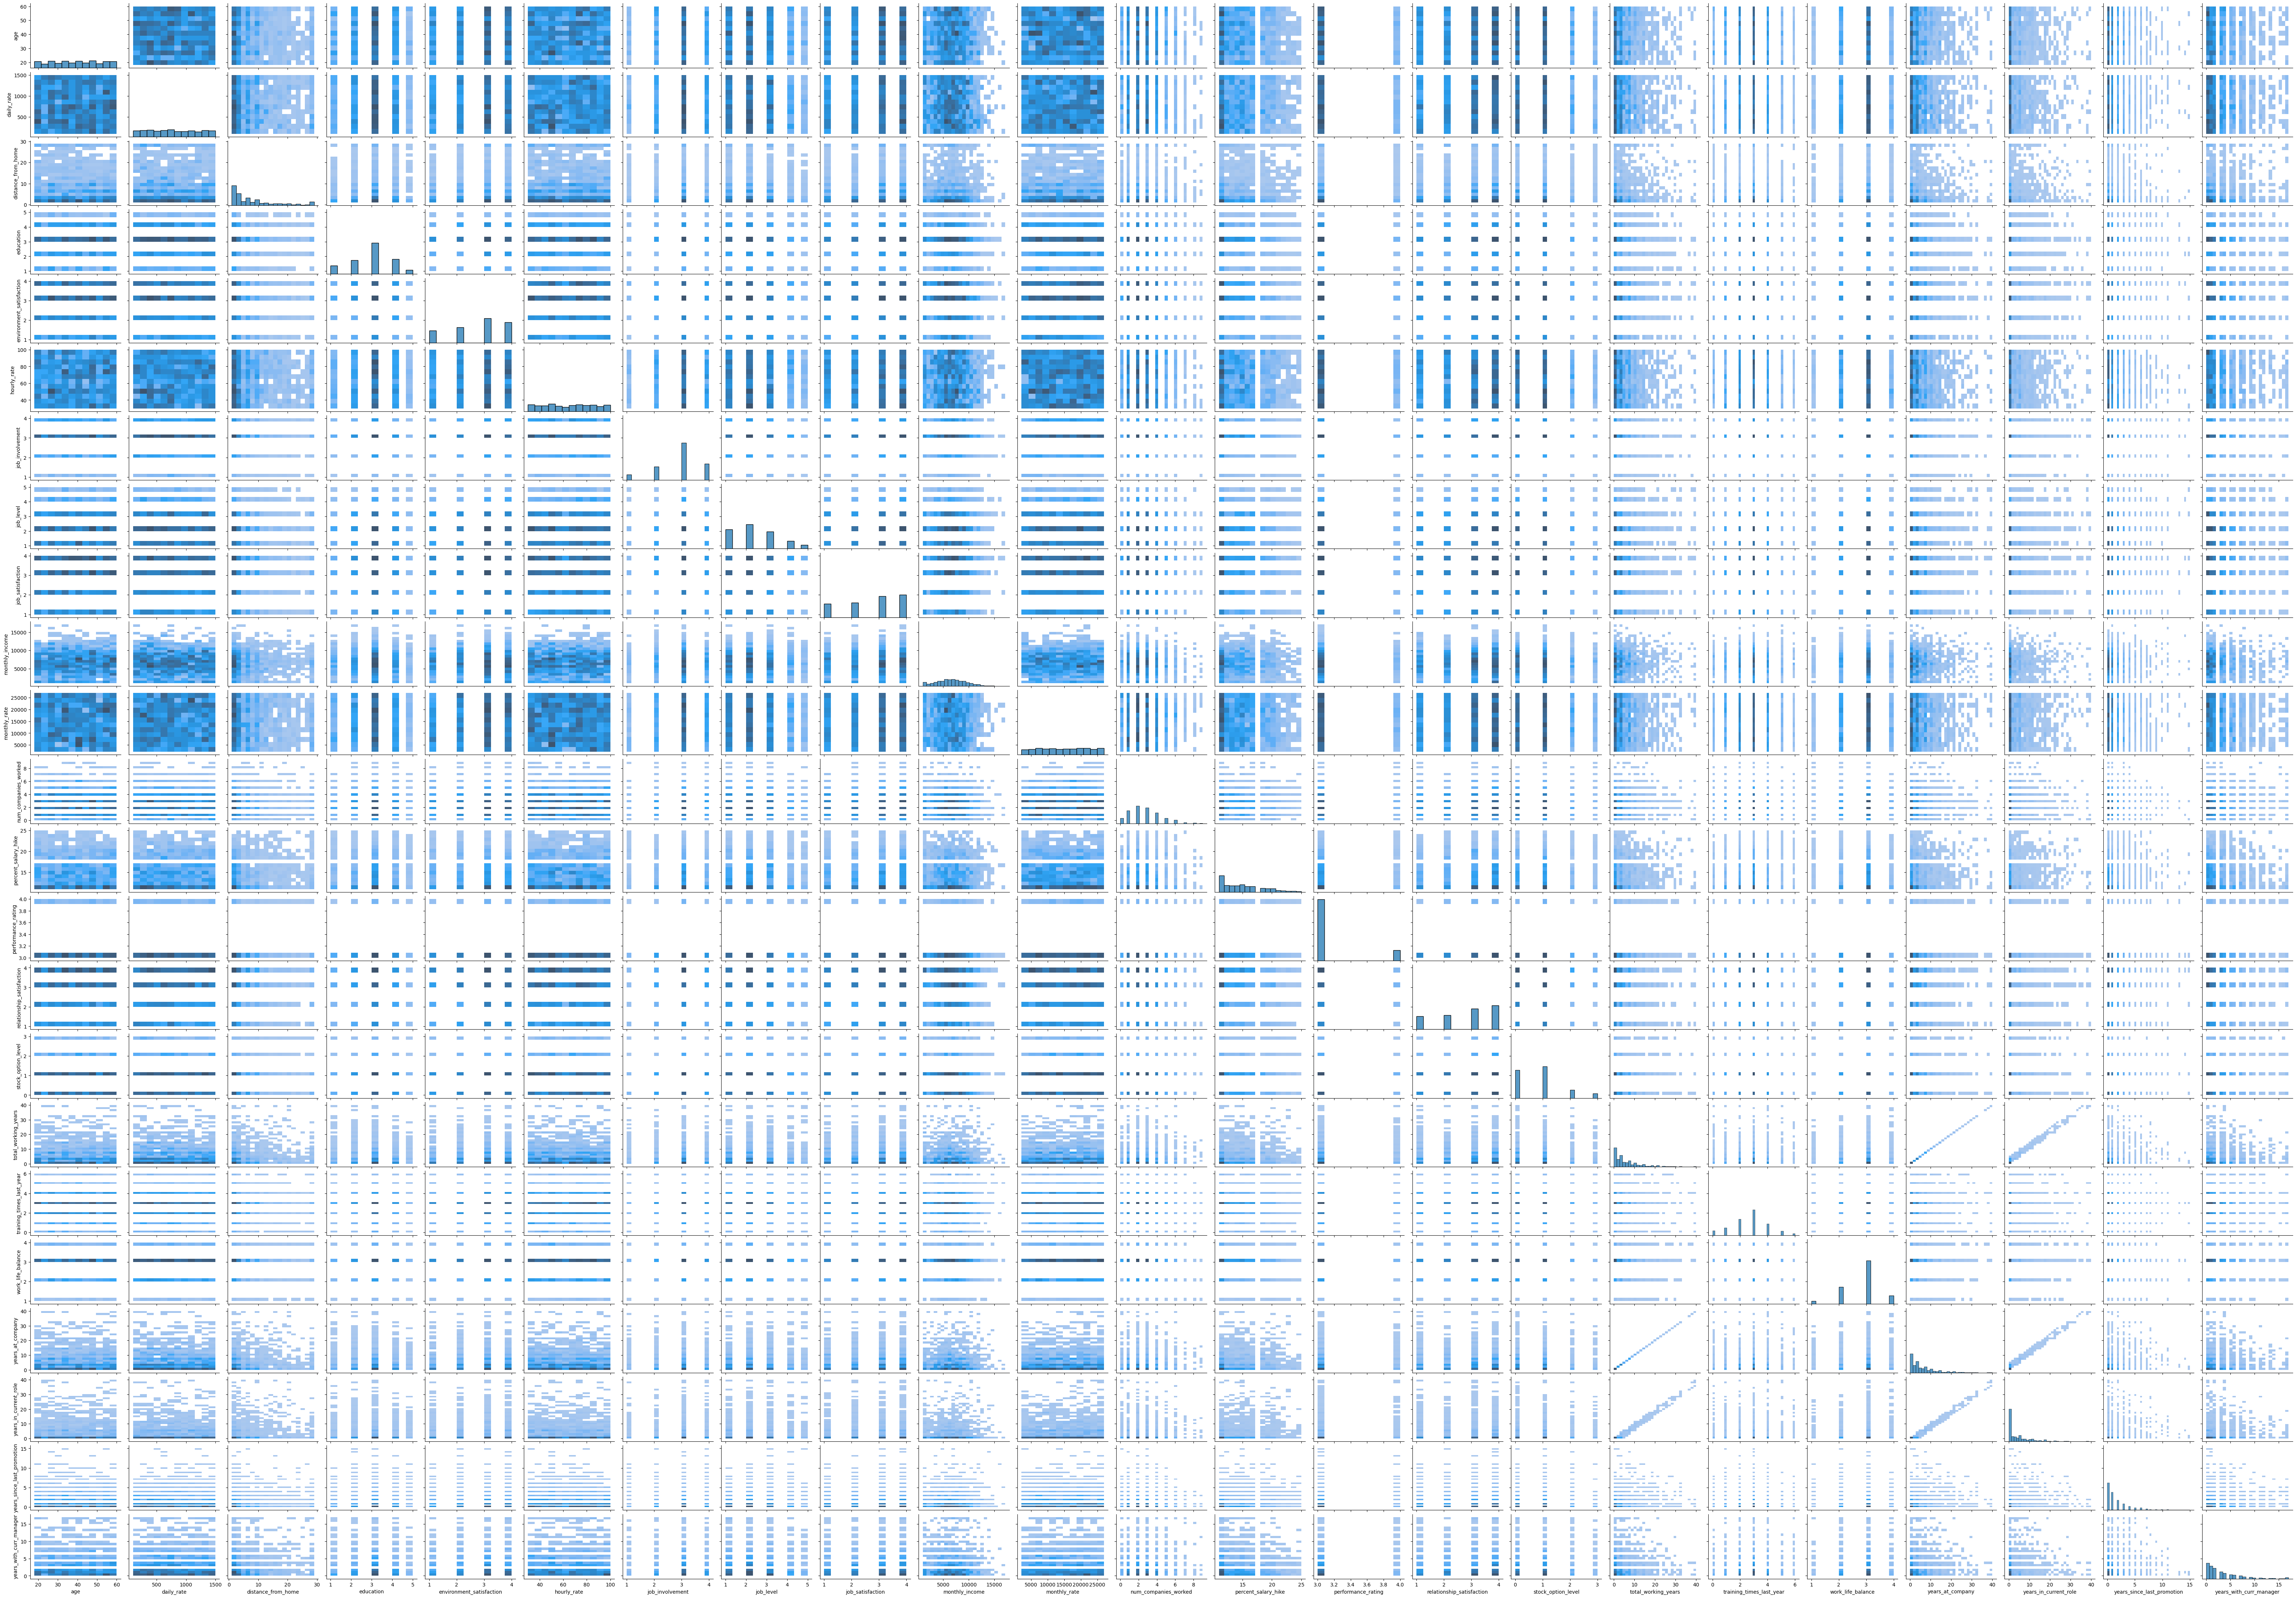

In [9]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(65, 45)

### Data Pre-Processing

In [10]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
object_cols = df.select_dtypes(include='object').columns.tolist()

# Print the lists
print("Numeric Columns:")
print(numeric_cols)

print("\nObject Columns:")
print(object_cols)

Numeric Columns:
['age', 'daily_rate', 'distance_from_home', 'education', 'environment_satisfaction', 'hourly_rate', 'job_involvement', 'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate', 'num_companies_worked', 'percent_salary_hike', 'performance_rating', 'relationship_satisfaction', 'stock_option_level', 'total_working_years', 'training_times_last_year', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager']

Object Columns:
['business_travel', 'department', 'education_field', 'gender', 'job_role', 'marital_status', 'over_time', 'attrition']
